Linear fit coefficients:
Slope: 1.192184e+00
Intercept: 1.212277


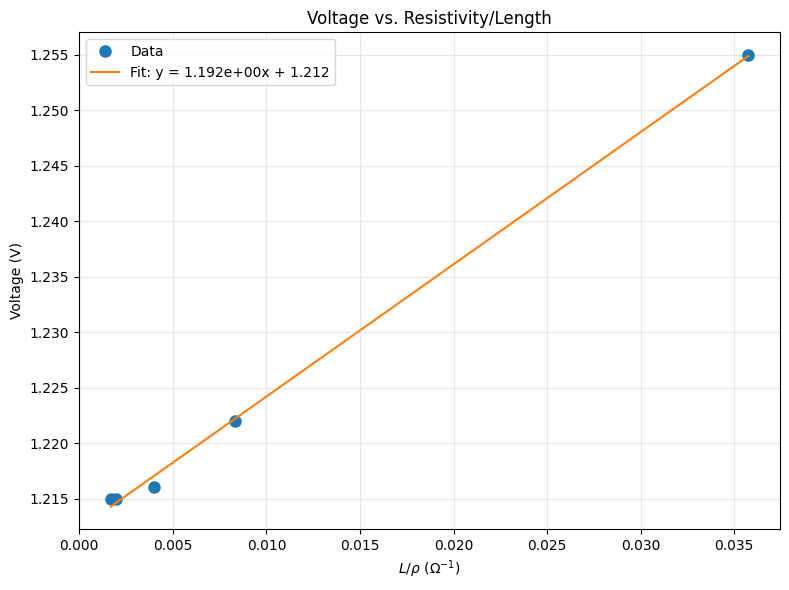

In [10]:
# Task 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as p

# import csv - note: CSV has spaces after commas, need to handle
data = pd.read_csv('data1.csv', skipinitialspace=True)

# plot the data
# Convert units: res is in ohm*cm, l is in micrometers
# Calculate res/l in units of ohm
# res/l = (ohm*cm) / (micrometer) = (ohm*cm) / (10^-4 cm) = 10^4 ohm
data['res_over_l'] = data['res'] / data['l'] * 1e4
data['l_over_res'] = 1 / data['res_over_l']

# Perform linear fit
coeffs = np.polyfit(data['l_over_res'], data['v'], 1)
slope = coeffs[0]
intercept = coeffs[1]

# Print coefficients
print(f"Linear fit coefficients:")
print(f"Slope: {slope:.6e}")
print(f"Intercept: {intercept:.6f}")

# Plot voltage vs res/l
p.figure(figsize=(8, 6))
p.plot(data['l_over_res'], data['v'], 'o', markersize=8, label='Data')
# Plot fit line
x_fit = np.linspace(data['l_over_res'].min(), data['l_over_res'].max(), 100)
y_fit = slope * x_fit + intercept
p.plot(x_fit, y_fit, '-', label=f'Fit: y = {slope:.3e}x + {intercept:.3f}')
p.xlabel(r'$L/\rho$ ($\Omega^{-1}$)')
p.ylabel('Voltage (V)')
p.title('Voltage vs. Resistivity/Length')
p.legend()
p.grid(True, alpha=0.3)
p.tight_layout()
p.show()






In [ ]:
# lab2

# 1. 

N_Fe = 7.36*(10**10) # 1/cm3
tau_before = 164.09 # micros
tau_after = 209.06 # micros

C = N_Fe / ((1/tau_before)-(1/tau_after))
print(f"C = {C:.6e} cm^3·µs")
# we got a much different value than expected, because the tau values were much smaller than expected
# the values we used are averaged (the taus are averaged across the whole sample)
# and then we use those, but we should actually first calculate the C for each point and then do the averaging
# we will do this at home

# 2.
# Input prime tau values
tau_before_prime = 136.50 # micros
tau_after_prime = 142.67 # micros

N_Fe_prime = C * ((1/tau_before_prime)-(1/tau_after_prime))
print(f"N_Fe' = {N_Fe_prime:.6e} cm^-3")


C = 5.614460e+13 cm^3·µs
N_Fe' = 1.778803e+10 cm^-3
